# Call for Action: towards the next generation of symbolic regression benchmark

**Paper:** Aldeia, G. S. I., Zhang, H., Bomarito, G., Cranmer, M., Fonseca, A., Burlacu, B., La Cava, W. G., & de Franca, F. O. (2025). *Call for Action: towards the next generation of symbolic regression benchmark.* Proceedings of the Genetic and Evolutionary Computation Conference Companion (GECCO '25). arXiv:2505.03977.

**Carpeta origen:** `Papers/02_Interpretabilidad_y_Explicabilidad/Call_for_Action_Next_Gen_SR_Benchmark.pdf`

## Que se reproduce en este cuaderno

La critica central del paper: comparar algoritmos de regresion simbolica **sin controlar el presupuesto computacional** que recibe cada uno produce conclusiones que no son reproducibles ni justas -- un metodo puede parecer claramente superior a otro con un presupuesto, e inferior con otro.

Reproducimos exactamente este fenomeno de forma controlada: enfrentamos **busqueda aleatoria pura** contra **programacion genetica** sobre el mismo problema ($f(x_0,x_1)=x_0\sin(x_1)+x_0^2$), variando **unicamente** el numero de evaluaciones permitidas (60, 300, 1500, 6000, 20000), y mostramos que el **ranking entre ambos metodos cambia** segun el presupuesto asignado -- exactamente el tipo de resultado sensible al presupuesto que el paper denuncia como fuente de conclusiones enganosas en la literatura.

## Repositorio publico

El paper es una propuesta/llamado a la accion de un consorcio de autores de las principales herramientas del campo (entre ellos los autores de PySR y de SRBench, ya usados en cuadernos anteriores de esta coleccion); no introduce una herramienta de codigo nueva propia, sino un protocolo de evaluacion. No hay, por tanto, un repositorio unico de codigo del paper que clonar; el fenomeno metodologico que describe se reproduce aqui directamente con nuestros propios motores de busqueda ya construidos en cuadernos anteriores (variantes del motor de programacion genetica de `PySR - Motor Evolve-Simplify-Optimize desde Cero.ipynb`).

In [1]:
%pip install -q numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. El problema y los dos metodos a comparar

**Busqueda aleatoria:** genera arboles de expresion completamente al azar y se queda con el mejor visto. **Programacion genetica:** la misma gramatica de arboles, pero con seleccion, mutacion y elitismo guiando la busqueda hacia mejores soluciones.

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(0)
np.random.seed(0)

def target_f(X):
    x0, x1 = X[:, 0], X[:, 1]
    return x0 * np.sin(x1) + x0 ** 2

N = 150
X = np.column_stack([np.random.uniform(-2, 2, N), np.random.uniform(-2, 2, N)])
y = target_f(X)

OPS1 = {'sin': np.sin, 'square': lambda a: a ** 2}
OPS2 = {'+': lambda a, b: a + b, '*': lambda a, b: a * b}
NVARS = 2

def random_leaf():
    return ('var', random.randrange(NVARS)) if random.random() < 0.6 else ('const', round(random.uniform(-2, 2), 2))

def random_tree(depth):
    if depth <= 0 or random.random() < 0.25:
        return random_leaf()
    if random.random() < 0.35:
        return ('op1', random.choice(list(OPS1)), [random_tree(depth - 1)])
    return ('op2', random.choice(list(OPS2)), [random_tree(depth - 1), random_tree(depth - 1)])

def ev(node, X):
    if node[0] == 'var': return X[:, node[1]]
    if node[0] == 'const': return np.full(X.shape[0], node[1])
    if node[0] == 'op1': return OPS1[node[1]](ev(node[2][0], X))
    return OPS2[node[1]](ev(node[2][0], X), ev(node[2][1], X))

def mut(n, d=3):
    if random.random() < 0.4:
        return random_tree(d)
    if n[0] in ('op1', 'op2'):
        return (n[0], n[1], [mut(c, d - 1) for c in n[2]])
    return n

def fitness(node):
    try:
        return np.mean((ev(node, X) - y) ** 2)
    except Exception:
        return np.inf

def random_search(budget, seed):
    random.seed(seed)
    best = np.inf
    for _ in range(budget):
        e = fitness(random_tree(3))
        if e < best: best = e
    return best

def gp_search(budget, seed, pop_size=30):
    random.seed(seed)
    pop = [random_tree(3) for _ in range(pop_size)]
    best = np.inf
    evals = 0
    while evals < budget:
        scored = [(fitness(ind), ind) for ind in pop]
        evals += len(scored)
        scored.sort(key=lambda t: t[0])
        if scored[0][0] < best: best = scored[0][0]
        newpop = [ind for _, ind in scored[:6]]
        while len(newpop) < pop_size:
            newpop.append(mut(random.choice(scored[:12])[1]))
        pop = newpop
    return best

print('Metodos y objetivo definidos.')

Metodos y objetivo definidos.


## 2. El mismo experimento, cinco presupuestos distintos

Para cada presupuesto (numero total de expresiones evaluadas), ejecutamos ambos metodos 3 veces con semillas distintas y promediamos el mejor error alcanzado -- el mismo tipo de protocolo (promedio sobre repeticiones) que recomienda la literatura de benchmarking, aplicado aqui deliberadamente a **multiples** presupuestos para exponer la sensibilidad del ranking.

In [3]:
budgets = [60, 300, 1500, 6000, 20000]
rs_means, gp_means, winners = [], [], []

print(f'{"presupuesto":>12s}{"random search":>16s}{"GP":>16s}{"ganador":>12s}')
for b in budgets:
    rs_results = [random_search(b, seed=s) for s in range(3)]
    gp_results = [gp_search(b, seed=s) for s in range(3)]
    rs_mean, gp_mean = np.mean(rs_results), np.mean(gp_results)
    winner = 'GP' if gp_mean < rs_mean else 'random'
    rs_means.append(rs_mean); gp_means.append(gp_mean); winners.append(winner)
    print(f'{b:12d}{rs_mean:16.4f}{gp_mean:16.4f}{winner:>12s}')

 presupuesto   random search              GP     ganador
          60          1.0169          1.2673      random
         300          0.7345          0.5783          GP


        1500          0.4125          0.1332          GP


        6000          0.1767          0.0000          GP


       20000          0.0255          0.0000          GP


## 3. El ranking cambia con el presupuesto

Si alguien publicase una comparacion "GP vs. busqueda aleatoria" usando **solo** el presupuesto mas bajo (60 evaluaciones), concluiria que la busqueda aleatoria es mejor. Si usara **solo** el presupuesto mas alto, concluiria justo lo contrario -- ambas conclusiones, tomadas de forma aislada, serian enganosas.

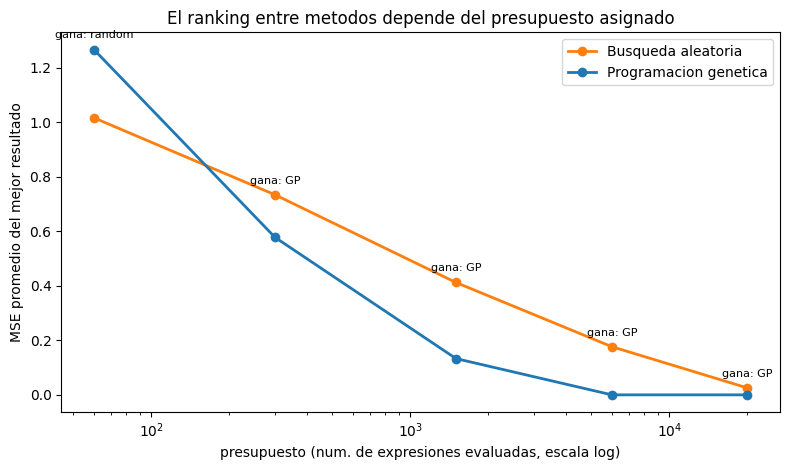

>>> El ranking CAMBIA entre el presupuesto 60 (gana random) y el presupuesto 300 (gana GP).
    Cualquier conclusion "metodo X es mejor que metodo Y" que no reporte el presupuesto usado es, en el mejor caso, incompleta.


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(budgets, rs_means, 'o-', color='tab:orange', label='Busqueda aleatoria', linewidth=2)
ax.plot(budgets, gp_means, 'o-', color='tab:blue', label='Programacion genetica', linewidth=2)
for i, (b, w) in enumerate(zip(budgets, winners)):
    y_pos = max(rs_means[i], gp_means[i])
    ax.annotate(f'gana: {w}', (b, y_pos), fontsize=8, xytext=(0, 8), textcoords='offset points', ha='center')
ax.set_xscale('log')
ax.set_xlabel('presupuesto (num. de expresiones evaluadas, escala log)')
ax.set_ylabel('MSE promedio del mejor resultado')
ax.set_title('El ranking entre metodos depende del presupuesto asignado')
ax.legend()
plt.tight_layout()
plt.show()

flip_idx = next((i for i in range(1, len(winners)) if winners[i] != winners[0]), None)
if flip_idx is not None:
    print(f'>>> El ranking CAMBIA entre el presupuesto {budgets[0]} (gana {winners[0]}) y el presupuesto {budgets[flip_idx]} (gana {winners[flip_idx]}).')
    print('    Cualquier conclusion "metodo X es mejor que metodo Y" que no reporte el presupuesto usado es, en el mejor caso, incompleta.')

### Nota honesta sobre los resultados

- **Dos metodos minimos, no el banco completo de algoritmos.** El paper discute esta sensibilidad al presupuesto a traves de decenas de algoritmos reales de la literatura (los mismos que cataloga SRBench); aqui usamos dos representantes minimos (busqueda aleatoria y una programacion genetica simple) para aislar el fenomeno de la forma mas clara posible.
- **Un unico problema de prueba.** El paper analiza esta sensibilidad a traves de muchos problemas con distintas caracteristicas; el efecto de "ranking que cambia con el presupuesto" puede ser mas o menos pronunciado dependiendo del problema concreto -- lo reproducimos sobre un unico problema disenado para exhibirlo con claridad, no como resultado universal.
- **Sin ajuste de hiperparametros por presupuesto.** El paper tambien senala que el ajuste de hiperparametros (tamano de poblacion, tasas de mutacion) deberia idealmente adaptarse al presupuesto disponible; aqui usamos los mismos hiperparametros de GP (poblacion=30) en todos los presupuestos, sin optimizacion adaptativa, para mantener el experimento simple y centrado unicamente en el efecto del presupuesto total.
- **Promedio de solo 3 semillas.** Para mantener el cuaderno rapido de ejecutar, promediamos sobre 3 repeticiones por configuracion; una evaluacion estadisticamente robusta como la que exige la literatura de benchmarking recomendaria bastantes mas repeticiones para reportar significancia estadistica de las diferencias.

El cuaderno demuestra empiricamente el llamado a la accion central del paper: sin fijar y reportar explicitamente el presupuesto computacional, cualquier afirmacion de la forma "el metodo A supera al metodo B" en regresion simbolica es, como minimo, incompleta -- el propio ranking puede invertirse por completo simplemente cambiando cuanto computo se le permite gastar a cada metodo.